[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Розмір вибірки:
 (5000, 2)
  label                                               text
0     1  while we may have high expectations of our ass...
1     0  sorry ,\ndon ' t we need to know the cost , as...
2     0  paul received the standard business reorg pack...
3     0  mathew 写道 what does gr do it's qr not gr see p...
4     0   croero hotmail com wrote hello i need to impo...
----------
Числовий розподіл повідомлень:
 label
Spam     2603
Ham      2396
label       1
Name: count, dtype: int64
----------


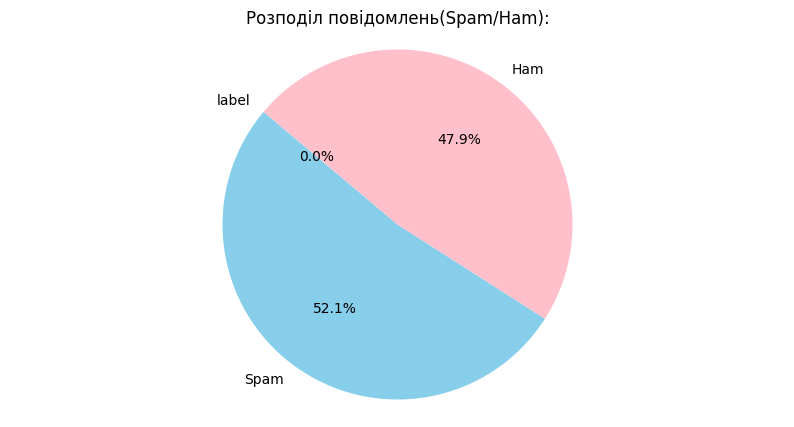

----------
test_1 HAM --- free registration
----------
test_2 HAM --- hi see tomorrow
----------
test_3 SPAM --- sale discount product
----------
test_4 SPAM --- please send report
----------
Слова, які найчастіше зустрічаються у спамі:

----------
escapenumber -> -2.875126484485145
----------
escapelong -> -3.581393316957099
----------
per -> -5.332353926692489
----------
pill -> -5.344082628582314
----------
http -> -5.387130882150828
----------
com -> -5.450067558871731
----------
price -> -5.540890631558722
----------
escapenumbermg -> -5.549132436453825
----------
escapenumbere -> -5.64762007282389
----------
company -> -5.670715787618539
----------
item -> -5.786165099928702
----------
save -> -5.852103201420697
----------
one -> -5.94703996822591
----------
product -> -6.0029912356131385
----------
may -> -6.040606289558866
----------
email -> -6.082039143295071
----------
time -> -6.1653185758776425
----------
please -> -6.201733522619421
----------
get -> -6.267420605971872
--

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


#стоп слова
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))


#читання даних
df = pd.read_csv('./combined_data.csv') 

#вибірка декількох тисяч записів 
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

#результат
print(f"Розмір вибірки:\n {df.shape}")
print(df.head())
print('----------')

#візуалізація к-сті повідомлень за двома класами
df['label'] = df['label'].astype(str).replace({'0': 'Ham', '0.0': 'Ham', '1': 'Spam', '1.0': 'Spam'})
counts = df['label'].value_counts()
print('Числовий розподіл повідомлень:\n', counts)
print('----------')

plt.figure(figsize=(10,5))
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'pink'], startangle=140)
plt.title('Розподіл повідомлень(Spam/Ham):')
plt.ylabel('')
plt.axis('equal') 
plt.show()

#обробка тексту
def preprocess(text):
    lemmatizer = WordNetLemmatizer()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['text'] = df['text'].apply(preprocess)

#тестова вибірка для перевірки 
test_email = {'test_1': 'Free registration', 'test_2': 'Hi, see you tomorrow?', 'test_3': 'Sale! Discounts on all products', 'test_4': 'Please send the report'}

#підготовка даних для перевірки
df['label'] = df['label'].str.strip()
df = df[df['label'].isin(['Ham', 'Spam'])]

x_train = df['text']
y_train = df['label'].map({'Ham': 0, 'Spam': 1})

#розбиваємо ключі і значення
x_test = list(test_email.values())
x_test = [preprocess(t) for t in x_test]
test_keys = list(test_email.keys())

#векторизація
vectorizer = CountVectorizer()
x_train_counts = vectorizer.fit_transform(x_train)
x_test_counts = vectorizer.transform(x_test)

#навчання
model = MultinomialNB()
model.fit(x_train_counts, y_train)

#аналіз spam/ham
predictions = model.predict(x_test_counts)

#результат
for key, text, pred in zip(test_keys, x_test, predictions):
    label = "SPAM" if pred == 1 else "HAM"
    print('----------')
    print(key, label, "---", text)

#беремо всі слова, які знає модель
feature_names = vectorizer.get_feature_names_out()

#беремо ймовірності для класу спам
spam_probs = model.feature_log_prob_[1]

#знаходимо індекси слів з найбільшою ймовірністю
top_indices = np.argsort(spam_probs)[-20:]

#виводимо топ слів для спаму
print('----------')
print("Слова, які найчастіше зустрічаються у спамі:\n")

for i in reversed(top_indices):
    word = feature_names[i]
    prob = spam_probs[i]
    print('----------')
    print(f"{word} -> {prob}")

